# Ideal Gas Under Gravity

Same hard-sphere gas as `Ideal Gas.ipynb`, but only the left/right walls reflect (no floor/ceiling) and a uniform downward gravity field is applied, so the gas sediments/falls instead of reaching a steady pressure. Uses the shared `ideal_gas.py` module -- this scenario previously used a slower all-pairs O(N^2) collision check instead of the spatial-hash approach; consolidating onto the shared module fixes that.

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import ideal_gas as ig

MEDIA = "media"
os.makedirs(MEDIA, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ig.configure_ffmpeg()

In [4]:
N = 20000
dt = 8e-6
t_steps = 2000
v0 = 500.0
radius = 0.0005

r = torch.rand((2, N), device=device)
ixr, ixl = r[0] > 0.5, r[0] <= 0.5
v = torch.zeros((2, N), device=device)
v[0][ixr] = -v0
v[0][ixl] = v0

rs, vs, _ = ig.motion(r, v, ts=t_steps, dt=dt, d_cutoff=2 * radius, L=1.0,
                      accel_fn=ig.uniform_gravity(g=-900000.0),
                      reflect_x_lo=True, reflect_x_hi=True, reflect_y_lo=True, reflect_y_hi=False,
                      track_pressure=False)

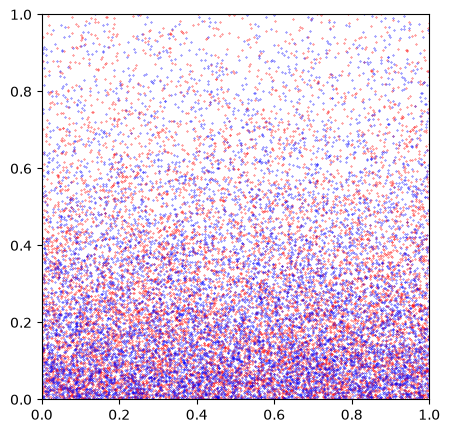

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
vmin, vmax = 0, 1
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
markersize = 2 * radius * ax.get_window_extent().width / (vmax - vmin) * 72. / fig.dpi
red, = ax.plot([], [], 'o', color='red', markersize=markersize)
blue, = ax.plot([], [], 'o', color='blue', markersize=markersize)

stride = ig.frame_stride(t_steps)
n_frames = t_steps // stride

def animate(frame):
    i = frame * stride
    xred, yred = rs[i][0][ixr].cpu(), rs[i][1][ixr].cpu()
    xblue, yblue = rs[i][0][ixl].cpu(), rs[i][1][ixl].cpu()
    red.set_data(xred, yred)
    blue.set_data(xblue, yblue)
    return red, blue

# Full t_steps (subsampled) so the settling onto the floor is actually visible, not just the initial fall
ani = animation.FuncAnimation(fig, animate, frames=n_frames, interval=20, blit=True)
ani.save(os.path.join(MEDIA, "ideal_gas_gravity.mp4"), writer="ffmpeg", fps=30)
plt.show()

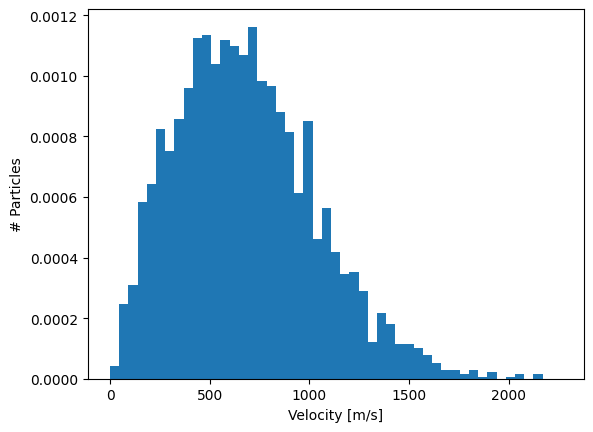

In [4]:
final_speeds = torch.sqrt(torch.sum(vs[-1]**2, axis=0)).cpu()
bins = np.linspace(0, final_speeds.max().item() * 1.05, 50)
fig, ax = plt.subplots()
ax.hist(final_speeds, bins=bins, density=True)
ax.set_xlabel('Velocity [m/s]')
ax.set_ylabel('# Particles')
fig.savefig(os.path.join(MEDIA, "gravity_final_speed_hist.png"), dpi=150, bbox_inches='tight')
plt.show()

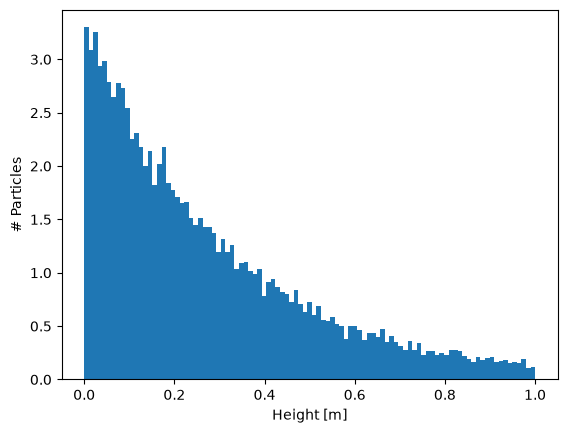

In [18]:
final_ys = rs[-1, 1].cpu()
bins = np.linspace(0, 1, 100)
fig, ax = plt.subplots()
ax.hist(final_ys, bins=bins, density=True)
ax.set_xlabel('Height [m]')
ax.set_ylabel('# Particles')
fig.savefig(os.path.join(MEDIA, "gravity_final_height_hist.png"), dpi=150, bbox_inches='tight')